# Đồ án 2: Data Fitting và Phương pháp OLS
## Phần 1: Lý thuyết Data Fitting và Minh họa

---

### 1. Ordinary Least Squares (OLS) 

#### 1.1. Công thức toán học
Mô hình hồi quy tuyến tính: $y = X\beta + \varepsilon$

- Nghiệm OLS (Normal Equations): $\hat{\beta}_{OLS} = (X^T X)^{-1} X^T y$
- Ma trận chiếu (Hat Matrix): $H = X(X^T X)^{-1} X^T$
- Ước lượng phương sai nhiễu ($\hat{\sigma}^2$): $\hat{\sigma}^2 = \frac{RSS}{n - (p+1)}$ (Trong đó $n$ là số quan sát, $p$ là số biến độc lập không tính intercept).
---

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from ols_implementation import ols_fit, hat_matrix, model_metrics, coef_inference, vif, run_monte_carlo
from ridge_lasso import ridge_fit, ridge_trace
from residual_analysis import get_residuals, get_standardized_residuals, cook_distance 
from cross_validation import kfold_cv


# 1. Sinh dữ liệu giả lập
np.random.seed(42)
n, p = 100, 3
X_base = np.random.randn(n, p)
X = np.hstack([np.ones((n, 1)), X_base]) # Thêm cột intercept
true_beta = np.array([2.5, 1.5, -2.0, 3.0])
y = X @ true_beta + np.random.normal(0, 1.0, n)

# 2. Cài đặt từ đầu
beta_hat, sigma2_hat = ols_fit(X, y)
# Chuyển beta_hat về array chỉ để in ra cho đẹp (làm tròn số)
print("Hệ số beta ước lượng (Self):", np.array(beta_hat).round(4))
print("Ước lượng sigma^2 (Self):", round(sigma2_hat, 4))

# 3. Kiểm chứng với Scikit-learn
model = LinearRegression(fit_intercept=False).fit(X, y)
print("Hệ số beta (Sklearn):     ", model.coef_.round(4))
assert np.allclose(beta_hat, model.coef_), "FAIL: Kết quả không khớp với Sklearn!"

Hệ số beta ước lượng (Self): [ 2.6129  1.4223 -2.05    2.8924]
Ước lượng sigma^2 (Self): 0.7883
Hệ số beta (Sklearn):      [ 2.6129  1.4223 -2.05    2.8924]


### 2. Ma trận chiếu (Hat Matrix)

Tính chất của $H$:
1. Idempotent: $H^2 = H$
2. Đối xứng: $H^T = H$
3. $rank(H) = p + 1$

In [7]:
# Tính toán ma trận Hat
H = hat_matrix(X)

# NumPy phục vụ việc kiểm chứng
H_np = np.array(H)

# 1. Kiểm tra tính Idempotent: H * H = H
is_idempotent = np.allclose(H_np @ H_np, H_np)

# 2. Kiểm tra tính đối xứng: H^T = H
is_symmetric = np.allclose(H_np.T, H_np)

print(f"Tính Idempotent (H^2 = H): {is_idempotent}")
print(f"Tính đối xứng (H^T = H): {is_symmetric}")

# 3. Rank của H (bằng p + 1 = 4)
print("Rank của H:", np.linalg.matrix_rank(H_np))


Tính Idempotent (H^2 = H): True
Tính đối xứng (H^T = H): True
Rank của H: 4


### 3. Đánh giá mô hình và Kiểm định thống kê

- RSS (Residual Sum of Squares): $\sum (y_i - \hat{y}_i)^2$
- $R^2$: Hệ số xác định.
- Adjusted $R^2$: Phạt khi thêm nhiều biến.
- F-test: Kiểm định ý nghĩa toàn bộ mô hình.
- t-test: Kiểm định ý nghĩa từng hệ số $\beta_j$.

In [9]:
# Tính y_hat
y_hat = X @ beta_hat
rss, tss, r2, r2_adj, f_stat, f_pvalue = model_metrics(y, y_hat, p)

print(f"Residual Sum of Squares (RSS): {rss:.4f}")
print(f"R-squared: {r2:.4f}")
print(f"Adj R-squared: {r2_adj:.4f}")
print(f"F-statistic: {f_stat:.4f} (p-value: {f_pvalue:.4e})")

# Suy diễn thống kê cho hệ số
se, t_stat, p_values, ci = coef_inference(X, y, beta_hat, sigma2_hat)

# Tạo bảng tổng hợp bằng Pandas
inference_df = pd.DataFrame({
    'Beta_Hat': beta_hat,
    'Std_Error': se,
    't_stat': t_stat,
    'p_value': p_values,
    'CI_Lower': ci[0],
    'CI_Upper': ci[1]
})

print("\nThống kê suy diễn hệ số:")
display(inference_df)


Residual Sum of Squares (RSS): 75.6763
R-squared: 0.9562
Adj R-squared: 0.9548
F-statistic: 698.4047 (p-value: 1.1102e-16)

Thống kê suy diễn hệ số:


,Beta_Hat,Std_Error,t_stat,p_value,CI_Lower,CI_Upper
0,2.612862,0.090950,28.728611,0.0,2.432328,2.793396
1,1.422337,0.109212,13.023575,0.0,1.205552,1.639122
2,-2.049964,0.092036,-22.273482,0.0,-2.232654,-1.867273
3,2.892407,0.081470,35.502699,0.0,2.730690,3.054123


### 4. Đa cộng tuyến (VIF)

VIF (Variance Inflation Factor) giúp phát hiện sự phụ thuộc tuyến tính giữa các biến độc lập.
$VIF_j = \frac{1}{1 - R_j^2}$

In [12]:
# Tính toán VIF cho các biến (loại trừ biến Intercept)
vif_vals = vif(X)

print("=== Kết quả Variance Inflation Factor (VIF) ===")
for i, val in enumerate(vif_vals):
    print(f"  VIF(X{i+1}) = {val:.4f}")

=== Kết quả Variance Inflation Factor (VIF) ===
  VIF(X1) = 1.0190
  VIF(X2) = 1.0198
  VIF(X3) = 1.0324


### 5. Ridge và Lasso Regression

Phương pháp hồi quy Ridge giải quyết bài toán đa cộng tuyến và overfitting bằng cách thêm thành phần phạt $L_2$ vào hàm mất mát:
- Nghiệm Ridge: $\hat{\beta}_{Ridge} = (X^T X + \lambda I)^{-1} X^T y$  
- Ridge Trace: Biểu đồ thể hiện sự thay đổi của các hệ số $\beta$ theo tham số điều chuẩn $\lambda$.

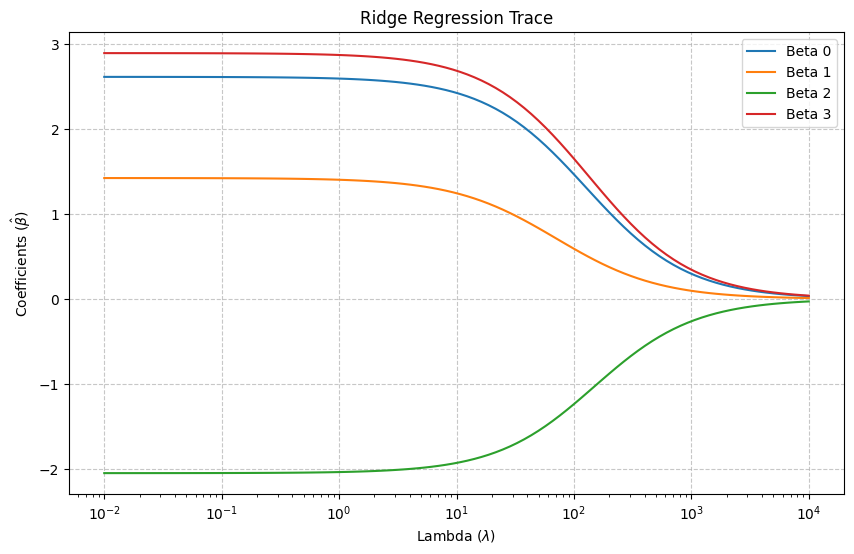

In [13]:
lam_list = np.logspace(-2, 4, 100)
# traces trả về danh sách các kết quả beta cho từng lambda
traces = ridge_trace(X, y, lam_list)

plt.figure(figsize=(10, 6))
# Chuyển traces sang numpy array để vẽ tất cả các cột cùng lúc
plt.plot(lam_list, np.array(traces))

plt.xscale('log')
plt.xlabel('Lambda ($\lambda$)')
plt.ylabel('Coefficients ($\hat{\\beta}$)')
plt.title('Ridge Regression Trace')
plt.legend([f'Beta {i}' for i in range(len(traces[0]))])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


### 6. Phân tích phần dư (Residual Analysis)

Sử dụng 4 biểu đồ để kiểm tra các giả thiết Gauss-Markov.
1. Residuals vs Fitted: Tuyến tính và đồng phương sai.
2. Normal Q-Q: Tính chuẩn của sai số.
3. Scale-Location: Kiểm tra đồng phương sai.
4. Cook's Distance: Xác định điểm ảnh hưởng lớn.

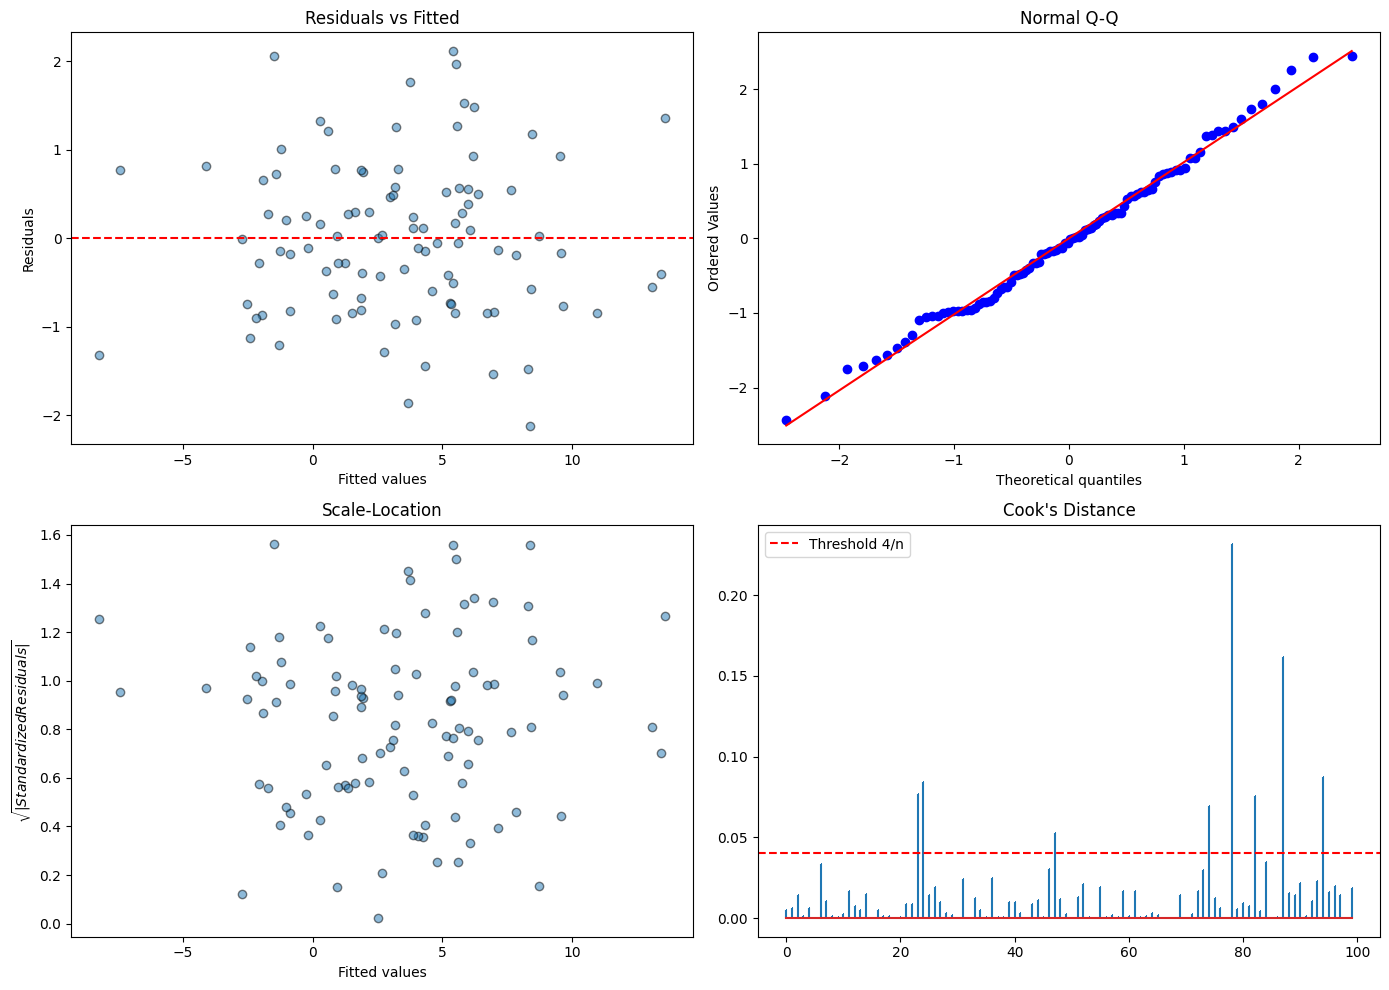

In [14]:
# 1. Gọi các hàm tính toán 
residuals = get_residuals(X, y, beta_hat)
std_residuals, h_ii = get_standardized_residuals(X, residuals, sigma2_hat)
cooks_d = cook_distance(std_residuals, h_ii, p)

# 2. Tính y_hat để làm trục hoành (Fitted values)
from ols_implementation import manual_matmul
y_hat = np.array(manual_matmul(X.tolist(), beta_hat))

# 3. Vẽ 4 biểu đồ chẩn đoán mô hình
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Biểu đồ 1: Residuals vs Fitted (Kiểm tra tính tuyến tính và phương sai nhiễu)
axs[0, 0].scatter(y_hat, residuals, alpha=0.5, edgecolors='k')
axs[0, 0].axhline(0, color='red', linestyle='--')
axs[0, 0].set_title('Residuals vs Fitted')
axs[0, 0].set_xlabel('Fitted values')
axs[0, 0].set_ylabel('Residuals')

# Biểu đồ 2: Normal Q-Q (Kiểm tra phân phối chuẩn của sai số)
import scipy.stats as stats
stats.probplot(std_residuals, dist="norm", plot=axs[0, 1])
axs[0, 1].set_title('Normal Q-Q')

# Biểu đồ 3: Scale-Location (Kiểm tra tính đồng nhất của phương sai)
axs[1, 0].scatter(y_hat, np.sqrt(np.abs(std_residuals)), alpha=0.5, edgecolors='k')
axs[1, 0].set_title('Scale-Location')
axs[1, 0].set_xlabel('Fitted values')
axs[1, 0].set_ylabel('$\sqrt{|Standardized Residuals|}$')

# Biểu đồ 4: Cook\'s Distance (Phát hiện các điểm có ảnh hưởng lớn/Outliers)
axs[1, 1].stem(np.arange(len(cooks_d)), cooks_d, markerfmt=",")
axs[1, 1].axhline(4/n, color='red', linestyle='--', label='Threshold 4/n')
axs[1, 1].set_title("Cook's Distance")
axs[1, 1].legend()

plt.tight_layout()
plt.show()


### 7. K-Fold Cross Validation

Đánh giá độ ổn định của mô hình trên dữ liệu chưa biết.

=== Kết quả 5-Fold Cross Validation (Tự cài đặt) ===
  Mean MSE: 0.836501
  MSE từng fold: [0.947446, 0.835893, 0.98306, 0.86578, 0.550324]


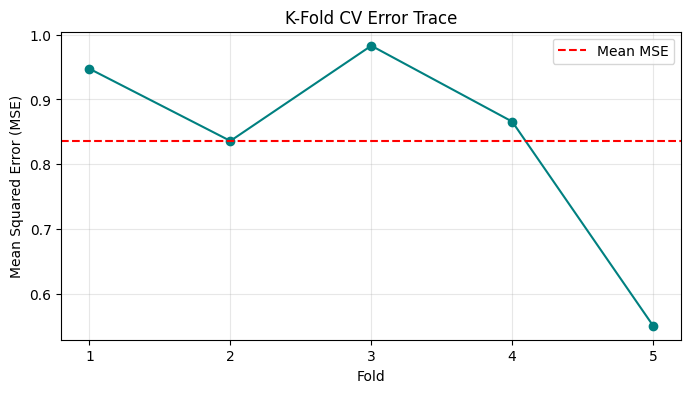

In [16]:
# Thực hiện k-Fold CV (kết quả trả về là trung bình MSE và danh sách MSE từng fold)
cv_score, mse_list = kfold_cv(X, y, k=5)

print(f"=== Kết quả 5-Fold Cross Validation (Tự cài đặt) ===")
print(f"  Mean MSE: {cv_score:.6f}")
print(f"  MSE từng fold: {[round(m, 6) for m in mse_list]}")

# Vẽ biểu đồ MSE qua các fold để trực quan hóa
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), mse_list, marker='o', linestyle='-', color='teal')
plt.axhline(cv_score, color='red', linestyle='--', label='Mean MSE')
plt.xlabel('Fold')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('K-Fold CV Error Trace')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 8. Minh họa định lý Gauss-Markov (Monte Carlo Simulation)

Sử dụng mô phỏng Monte Carlo để thực nghiệm kiểm chứng tính chất BLUE (Best Linear Unbiased Estimator):

1. Tính không chệch: $E[\hat{\beta}] = \beta$
2. Hiệu quả: OLS có phương sai nhỏ nhất trong lớp các ước lượng tuyến tính không chệch.


=== Kết quả mô phỏng Monte Carlo (1000 iterations) ===
True Beta:  [ 2.5  1.5 -2.   3. ]
Mean Beta (từ mô phỏng): [ 2.5006  1.5019 -2.0016  2.9965]

So sánh sai số (Bias): [ 0.000585  0.001863 -0.00162  -0.0035  ]


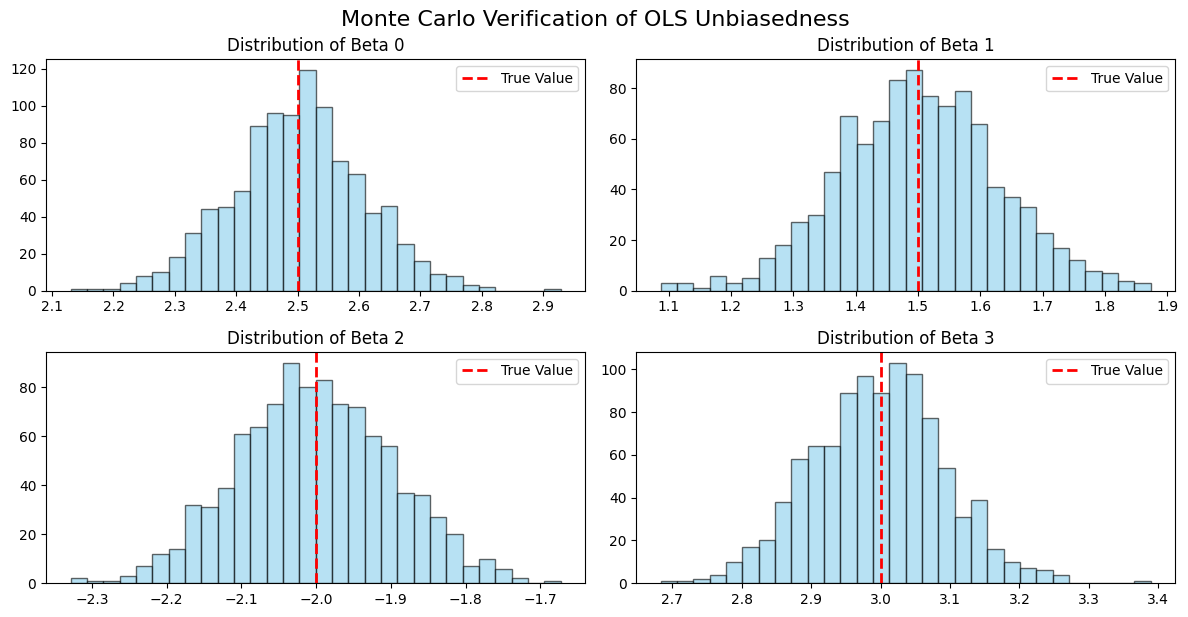

In [18]:
# Thực hiện mô phỏng Monte Carlo (1000 lần)
# true_beta đã được khai báo ở Cell 1 là: np.array([2.5, 1.5, -2.0, 3.0])
ols_betas = run_monte_carlo(X, true_beta, sigma=1.0, n_sims=1000)

# Chuyển về numpy để tính thống kê và vẽ hình
ols_betas_np = np.array(ols_betas)
mean_betas = np.mean(ols_betas_np, axis=0)

print("=== Kết quả mô phỏng Monte Carlo (1000 iterations) ===")
print("True Beta: ", true_beta)
print("Mean Beta (từ mô phỏng):", mean_betas.round(4))
print("\nSo sánh sai số (Bias):", (mean_betas - true_beta).round(6))

# Vẽ phân phối của các hệ số beta để kiểm chứng tính không chệch
plt.figure(figsize=(12, 6))
for i in range(len(true_beta)):
    plt.subplot(2, 2, i+1)
    plt.hist(ols_betas_np[:, i], bins=30, alpha=0.6, color='skyblue', edgecolor='black')
    plt.axvline(true_beta[i], color='red', linestyle='dashed', linewidth=2, label='True Value')
    plt.title(f'Distribution of Beta {i}')
    plt.legend()

plt.tight_layout()
plt.suptitle('Monte Carlo Verification of OLS Unbiasedness', y=1.02, fontsize=16)
plt.show()
